In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tools.etc import logo

NOTEBOOK_NAME = 'nsec1.ipynb'

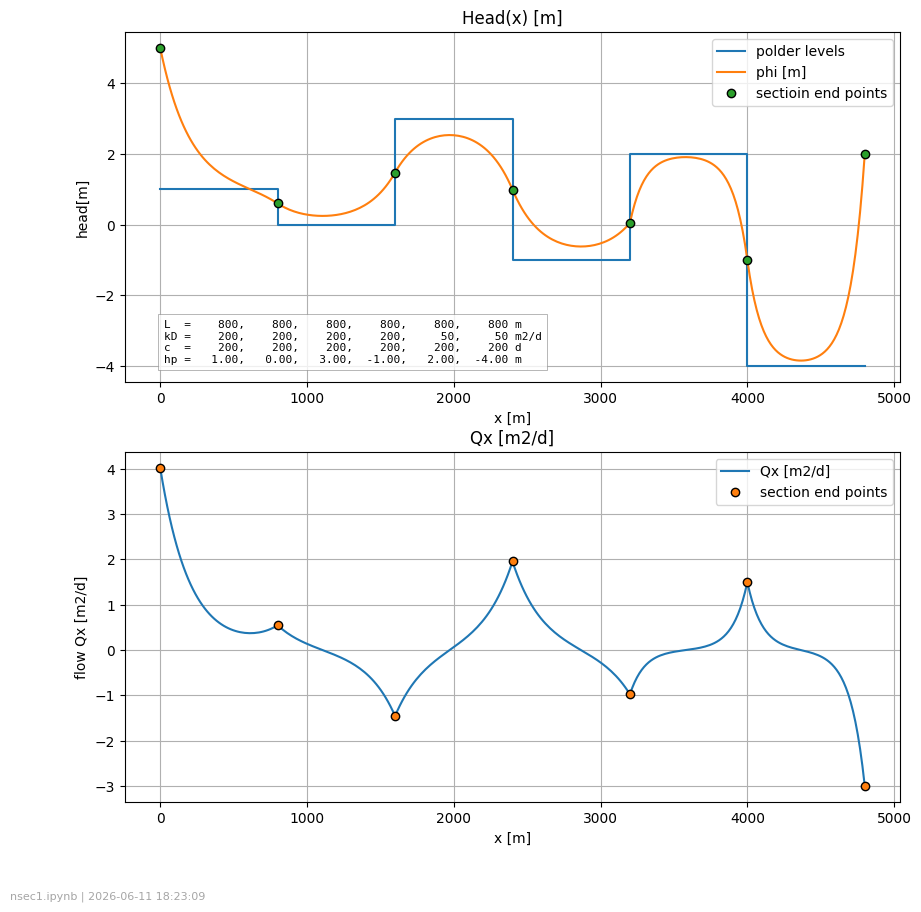

In [9]:
"""Analytic groundwater 1 layer steady 1D flow simulation in a series of adjaect polders.

 Same as the old nsecn multilayer Matlab version, but now only 1 layer.

@TO 2026-06-11
"""

class Nsec1():
    """Class to analytically simulate stead state flow in a linked leaky aquifer.
    The 1D single layer aquifer consits of sections of length L[i].
    Each section has its now vertical resistance and its own transmissivity.
    At each connection point a flow Q may be injected.
    At both outer boundaries a head or a flow may be specified.
    Afterwords the head and flow along all sections can can be simulated.
    
    Simplified version of nsecn made in 2000.
    
    @ TO 2026-0610
    """
    
    def __init__(self, kD=None, c=None, L=None, X0=0.0, Np=51):
        self.kD = np.array(kD, dtype=float)
        self.c  = np.array( c, dtype=float)
        self.L  = np.array( L, dtype=float)        
        if not all(np.array([len(kD), len(c), len(L)]) == len(kD)):
            raise ValueError("1D vectors kD, c and L must all have the same length.")
        self.X0 = X0
        self.Np = Np
        
    @property
    def X(self):
        """Return section end points as array."""
        return self.X0 + np.hstack((0, np.cumsum(self.L)))
        
        
    @property
    def x(self):
        """Return x coordinates spanning the entire area.
        
        You may inject the number of points per section by
        injectiong the variable Np into the instantiated class.
        
        mdl = Nsec1(...)
        mdl.Np = 51
        
        """
        x = np.array([self.X[0]], dtype=float)
        for x1, x2 in zip(self.X[:-1], self.X[1:]):
            x = np.hstack((x, np.linspace(x1, x2, self.Np)[1:]))
        return x
        
    @property
    def Nsec(self):
        """Return number of sections."""
        return len(self.kD)
        
    @property
    def lam(self):
        """Return spreading lengths."""
        return np.sqrt(self.kD * self.c)
    
    # --- Matrix coordinates kernel (submatrix)
    def coefsAB(self, i):
        """Return 2x4 kernel coefficient matrix truncated to 2x2 at both outer nodes.
        
        Note 0 is the left node of section 0
        
        """
        N = len(self.kD)
        
        eL = 0 if i<0   else np.exp(-self.L[i-1] / self.lam[i-1])
        eR = 0 if i>= N else np.exp(-self.L[i]   / self.lam[i])
        
        fL = 0 if i<0  else self.kD[i-1] / self.lam[i-1]
        fR = 0 if i>=N else self.kD[i]   / self.lam[i]
        
        M = np.array([
            [     eL,   1,  -1,     -eR],
            [fL * eL, -fL, -fR, fR * eR],
        ], dtype=float)
        if i == 0:
            M = M[:, 2:]
        if i == N:
            M = M[:, :2]
        return M

    @property
    def coefMat(self):
        """Return coefficient matrix."""
        N = len(self.kD)
        A = np.zeros((2*(N + 1), 2*N))
        for i in range(N + 1):
            M = self.coefsAB(i)            
            
            j0 = max(0, 2 * (i - 1))
            j1 = min(2 * N, j0 + M.shape[1])
                
            A[2*i:2*i+2, j0:j1] = M
        return A
    
    def set_boundaries(self, Phi=None, Q=None):
        # --- Boundary conditions
        RHS = np.zeros(2*(self.Nsec + 1))
        h = np.hstack((Phi[0], self.h, Phi[-1]))
        RHS[::2] = + h[1:] - h[:-1]
        RHS[1::2] = Q
        
        # --- Make Q equation or Phi equation at left and right inactive depending boundary type.
        active = np.ones(2 * (self.Nsec + 1), dtype=bool)
        
        if not np.isnan(Phi[0]):
            # --- Phi is given at left end
            # --- Q equation is inactive
            # RHS[0] = -Phi[0]
            active[0] = True
            active[1] = False
        else:
            # --- Q is given at left end
            # --- Phi equation is inactive
            active[0] = False
            active[1] = True    
            
        if not np.isnan(Phi[-1]):
            # --- Phi is given at right end
            # --- Q equation inactive
            # RHS[-2] = Phi[-1]
            active[-2] = True
            active[-1] = False
        else:
            # --- Q given at right end
            # --- Phi-equation inactive    
            active[-2] = False
            active[-1] = True
        return RHS, active


    def simulate(self, Phi=None, Q=None, h=None, x=None, Np=51):
        """Return heads and flow given the boundaries.
        
        Parameters
        ----------
        Phi: sequence of 2
            Heads at left and righ boundary. Use np.nan to use Q as boundary.
        Q: None | sequence of 2 or sequence of Nsec + 1 (numer of Nodes)
            Flow boundary conditions. None to use zeros, seq. of 2 to use these
            at either end and 0 for intermediate points. Use squence of Nsec + 1 
            to specify Q at all intermediate points.
            Specificagion of Phi determines wheather the edge Q values will be used.
        h: sequence of float (Nsec)
            Adjacent head in each section ("polder level")
        x: None or seqence of increasing x-coordinates
           None will span x between self.X with Np points per section
        Np: int
           Number of coordinates per sectioin if x is None
           You may inject it into the instantiated class:
           
           mdl = Nsec1(...)
           mdl.Np = 51
           
        """
        self.Np = Np
        
        if h is None:
            self.h = np.zeros(self.Nsec)
        else:
            self.h = np.array(h, dtype=float)
            if len(self.h) != self.Nsec:
                raise ValueError(f"Number of heads must equal number of sections {self.Nsec}")
        
        # --- Boundary Q and injection at connection points
        if Q is None:
            Q = np.zeros(self.Nsec + 1)
        else:
            Q = np.array(Q, dtype=float)
            assert len(Q) == 2 or len(Q) == self.Nsec + 1, f"Q must have length 2 or {self.Nsec + 1} or be None."

        # --- Coordinates for plotting        
        if x is None:
            x = self.x
        
        # --- Coefficient matrix
        A = self.coefMat
        
        # --- RHS
        RHS, active = self.set_boundaries(Phi=Phi, Q=Q)
        
        # --- Solve for coefficients
        coefs = np.linalg.solve(A[active], RHS[active])
        
        # --- Compute heads and flows for all x
        phi, Qx = self.get_phi_Q(coefs, x)
        
        return {'phi': phi, 'Qx':Qx}        

    def get_phi_Q(self, coefs, x):
        """Return heads and flows."""
        CA, CB = coefs[0::2], coefs[1::2]
        
        # --- Initialize heads and flows
        phi = np.zeros_like(x, dtype=float)
        Q   = np.zeros_like(x, dtype=float)
        
        # --- For each section compute heads and flows
        for i in range(self.Nsec):
            mask = (x >= self.X[i]) & (x <= self.X[i+1])
            eL = np.exp(-(x[mask] - self.X[i  ]) / self.lam[i])
            eR = np.exp(-(self.X[i+1] - x[mask]) / self.lam[i])    
            phi[mask] = CA[i] * eL + CB[i] * eR + self.h[i]
            Q[ mask]  = self.kD[i] / self.lam[i] * (CA[i] * eL - CB[i] * eR)
        return phi, Q


# --- Aquifer traject properties
L = np.array([800., 800., 800., 800, 800., 800.])
c = np.array([200., 200., 200., 200., 200., 200.])
kD = np.array([800., 800., 800., 800., 200., 200.]) / 4
h = np.array([1., 0., 3., -1., 2, -4])

# =Q =========================== Specify injections at every node including the outer two
Q = np.array([0., 0., 0., 0., 0., 0., 0.])

# =HEAD======================
Phi = np.array([5., 2.])


# --- Coordinates of the nodes (must (or should be) incresing)
X = np.hstack((0, np.cumsum(L)))

# --- Any set of coordinates will do. The nodes are included automatically.
x = np.unique(np.hstack((np.linspace(0, np.sum(L), 161), np.cumsum(L))))


Xp = np.hstack((0, np.cumsum(L)))
x  = np.linspace(Xp[0], Xp[-1], 201)

mdl = Nsec1(kD=kD, c=c, L=L)
Xp = mdl.X

outx = mdl.simulate(Phi=Phi, Q=Q, h=h, x=None)
outp = mdl.simulate(Phi=Phi, Q=Q, h=h, x=Xp)    

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
ax1.step(mdl.X, np.hstack((mdl.h, mdl.h[-1])), where='post', label='polder levels')
ax1.plot(mdl.x,  outx['phi'], label='phi [m]')
ax1.plot(Xp,     outp['phi'], 'o', mec='k', label='sectioin end points')

ax2.plot(mdl.x, outx['Qx'],  label='Qx [m2/d]') 
ax2.plot(mdl.X, outp['Qx'], 'o', mec='k', label='section end points') 

# --- Inset table with used properties
props_txt = [
    f"L  = {', '.join([f'{el:6.0f}' for el in  L])} {'m':4}",
    f"kD = {', '.join([f'{kd:6.0f}' for kd in kD])} {'m2/d'}",
    f"c  = {', '.join([f'{c_:6.0f}' for c_ in  c])} {'d':4}",
    f"hp = {', '.join([f'{h_:6.2f}' for h_ in  h])} {'m':4}", 
]


ax1.text(
    0.05, 0.05, '\n'.join(props_txt),
    transform=ax1.transAxes,
    ha='left', va='bottom',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)


ax1.set_title('Head(x) [m]')
ax1.set(xlabel='x [m]', ylabel='head[m]')
ax1.grid(True)

ax2.set_title('Qx [m2/d]')
ax2.set(xlabel='x [m]', ylabel='flow Qx [m2/d]')
ax2.grid(True)

ax1.legend()
ax2.legend()

logo(fig, NOTEBOOK_NAME)
images = '/Users/Theo/Development/python/hydro_tools/tools/analytic/images'
fig.savefig(os.path.join(images, 'example_nsec1.pdf'))

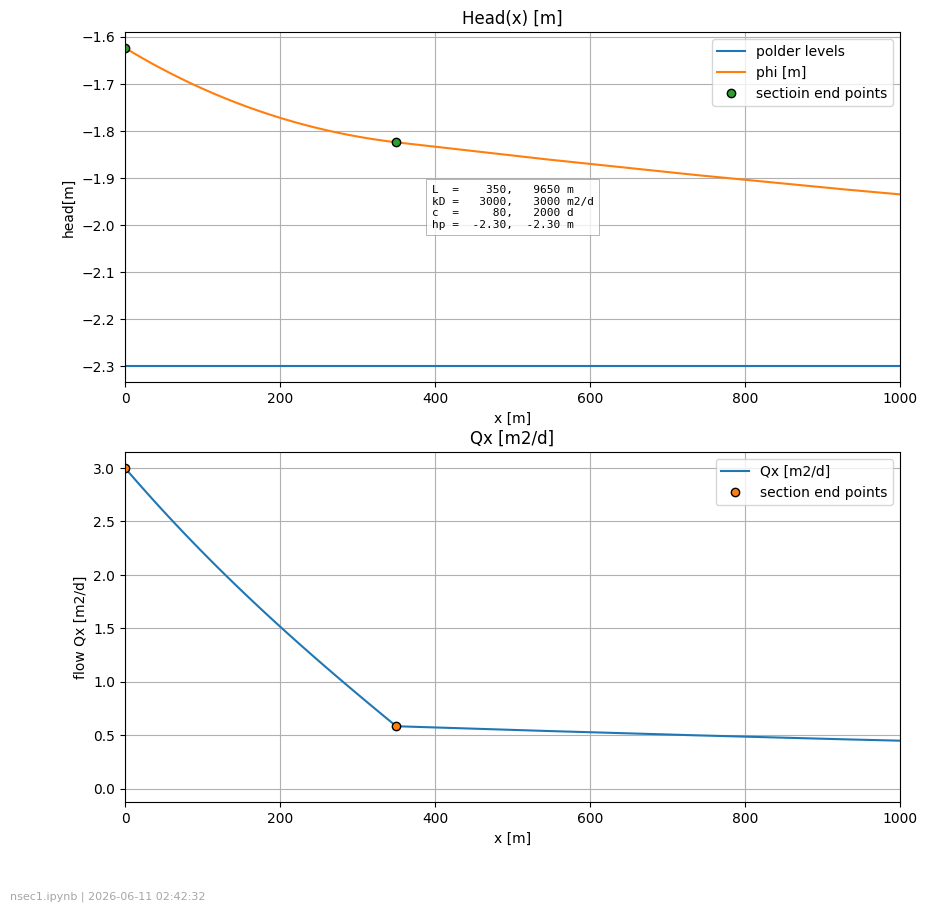

In [3]:

# --- Aquifer traject properties
L = np.array([  350., 9650])
c = np.array([  80., 2000])
kD = np.array([3000., 3000.])
h = np.array([-2.3, -2.3])

# =Q =========================== Specify injections at every node including the outer two
Q = np.array([-3., 0., 0.])

# =HEAD======================
Phi = np.array([np.nan, -2.3])


mdl = Nsec1(kD=kD, c=c, L=L)
Xp = mdl.X

outx = mdl.simulate(Phi=Phi, Q=Q, h=h, x=None)
outp = mdl.simulate(Phi=Phi, Q=Q, h=h, x=Xp)    

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
ax1.step(mdl.X, np.hstack((mdl.h, mdl.h[-1])), where='post', label='polder levels')
ax1.plot(mdl.x,  outx['phi'], label='phi [m]')
ax1.plot(Xp,     outp['phi'], 'o', mec='k', label='sectioin end points')

ax2.plot(mdl.x, outx['Qx'],  label='Qx [m2/d]') 
ax2.plot(mdl.X, outp['Qx'], 'o', mec='k', label='section end points') 

# --- Inset table with used properties
props_txt = [
    f"L  = {', '.join([f'{el:6.0f}' for el in  L])} {'m':4}",
    f"kD = {', '.join([f'{kd:6.0f}' for kd in kD])} {'m2/d'}",
    f"c  = {', '.join([f'{c_:6.0f}' for c_ in  c])} {'d':4}",
    f"hp = {', '.join([f'{h_:6.2f}' for h_ in  h])} {'m':4}", 
]


ax1.text(
    0.5, 0.5, '\n'.join(props_txt),
    transform=ax1.transAxes,
    ha='center', va='center',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)


ax1.set_title('Head(x) [m]')
ax1.set(xlabel='x [m]', ylabel='head[m]')
ax1.grid(True)

ax2.set_title('Qx [m2/d]')
ax2.set(xlabel='x [m]', ylabel='flow Qx [m2/d]')
ax2.grid(True)

xlim = (0, 1000)
ax1.set_xlim(xlim)
ax2.set_xlim(xlim)
ax1.legend()
ax2.legend()

logo(fig, NOTEBOOK_NAME)

Check Dinf @ D:
[[ 1.  0.]
 [-0.  1.]]
AB =[2.7803 1.6237]
FF = [3. 2.]


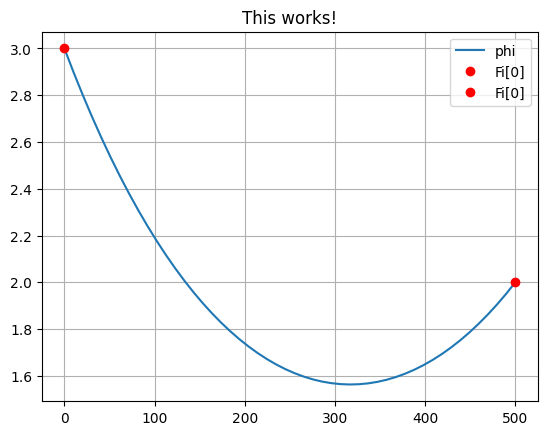

In [95]:
# --- Check the basic formula
# --- Mazure head between two boundaries
L, lam = 500., 250.
e = np.exp(-L/lam)

# --- Mazure matrix
D = np.array([[1, e],
              [e, 1]])

# --- Check inverse
Dinv = np.linalg.inv(D)
print(f"Check Dinf @ D:\n{(Dinv @ D).round(4)}")

# --- Head boundary condition on both sides
Fi = np.array([3, 2])

# --- Matrix coefficietns
AB = np.linalg.solve(D, Fi)
print(f"AB ={AB.round(4)}")

# --- Check to se that I get the Fi back using Dinv and AB
FF = np.linalg.solve(Dinv, AB)
print(f"FF = {FF.round(4)}")

# --- Split A,  B to compute the head between 0 and L
A, B = AB

x = np.linspace(0, L)
# --- Basic formula
phi = A * np.exp(-x/lam) + B * np.exp(-(L-x)/lam)

fig, ax = plt.subplots()
ax.set_title("This works!")
ax.grid()
ax.plot(x, phi, label='phi')
ax.plot(x[ 0], Fi[0], 'ro', label='Fi[0]')
ax.plot(x[-1], Fi[1], 'ro', label='Fi[0]')
ax.legend()

